LAB - 2

TASK - 6

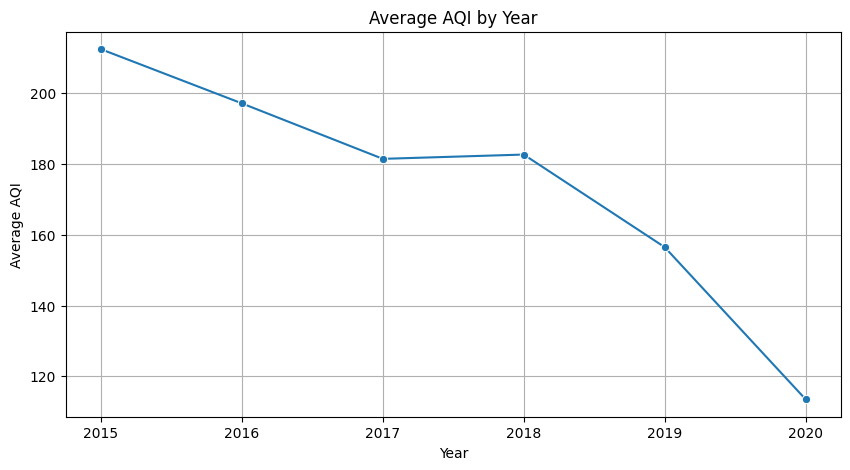

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


aqi = pd.read_csv("city_day (1).csv")
crop= pd.read_csv("crop_production (1).csv")

aqi["Date"] = pd.to_datetime(aqi["Date"])

aqi["Year"] = aqi["Date"].dt.year

yearly_aqi = aqi.groupby("Year")["AQI"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly_aqi,
    x="Year",
    y="AQI",
    marker="o"
)

plt.title("Average AQI by Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)

plt.show()


The graph shows how average AQI changed over the years.

The most polluted year was 2015 while the least polluted year was 2020.

Based on the overall trend, air quality appears to have LOWERED over the observed period. This suggests that pollution-control measures have been either effective, ineffective, or only partially effective depending on the direction of the trend.

TASK - 7

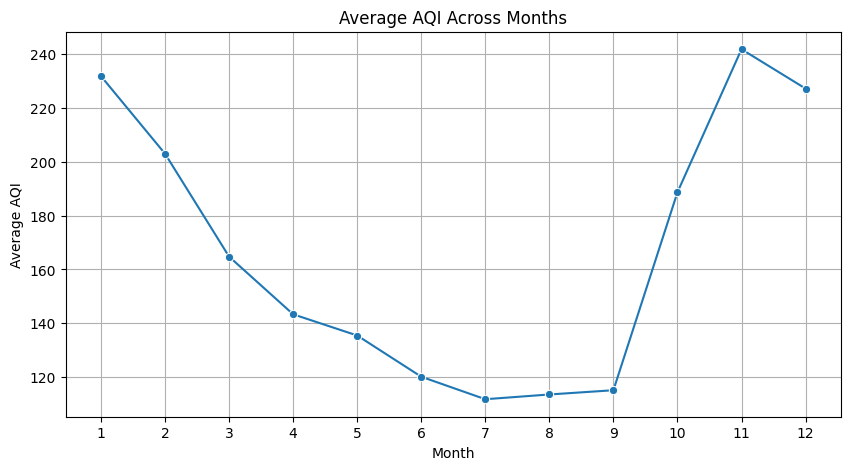

In [4]:
aqi["Month"] = aqi["Date"].dt.month

monthly_aqi = (
    aqi.groupby("Month")["AQI"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_aqi,
    x="Month",
    y="AQI",
    marker="o"
)

plt.title("Average AQI Across Months")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.xticks(range(1,13))
plt.grid(True)

plt.show()


The analysis shows that AQI levels are highest during __NOVEMBER__.

If AQI peaks during October–December, the NGO's claim is supported by the data.

Possible reasons include:

- Crop residue burning
- Winter atmospheric conditions
- Reduced wind circulation

If another period shows higher AQI, then the claim is not fully supported.

TASK - 8

The AQI dataset is recorded at the city-day level, whereas the crop dataset is recorded at the state-year level. Direct merging is therefore not possible. To combine the datasets, city observations would first need to be mapped to their corresponding states and aggregated annually. Since the AQI dataset provided does not contain state information, an external city-to-state mapping would be required before a meaningful merge can be performed.

In [12]:
print(sorted(aqi["City"].dropna().unique()))

['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [13]:
city_state = {
    "Ahmedabad": "Gujarat",
    "Aizawl": "Mizoram",
    "Amaravati": "Andhra Pradesh",
    "Amritsar": "Punjab",
    "Bengaluru": "Karnataka",
    "Bhopal": "Madhya Pradesh",
    "Brajrajnagar": "Odisha",
    "Chandigarh": "Chandigarh",
    "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu",
    "Delhi": "Delhi",
    "Ernakulam": "Kerala",
    "Gurugram": "Haryana",
    "Guwahati": "Assam",
    "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan",
    "Jorapokhar": "Jharkhand",
    "Kochi": "Kerala",
    "Kolkata": "West Bengal",
    "Lucknow": "Uttar Pradesh",
    "Mumbai": "Maharashtra",
    "Patna": "Bihar",
    "Shillong": "Meghalaya",
    "Talcher": "Odisha",
    "Thiruvananthapuram": "Kerala",
    "Visakhapatnam": "Andhra Pradesh"
}

In [7]:
aqi["Year"] = pd.to_datetime(aqi["Date"]).dt.year

In [14]:
# Convert date to year
aqi["Date"] = pd.to_datetime(aqi["Date"])
aqi["Year"] = aqi["Date"].dt.year

# Map cities to states
aqi["State"] = aqi["City"].map(city_state)

# Remove cities that couldn't be mapped
aqi = aqi.dropna(subset=["State"])

# Aggregate AQI to state-year level
state_year_aqi = (
    aqi.groupby(["State", "Year"])["AQI"]
    .mean()
    .reset_index()
)

# Aggregate crop data to state-year level
crop_agg = (
    crop.groupby(["State_Name", "Crop_Year"])[["Area", "Production"]]
    .sum()
    .reset_index()
)

# Rename columns to match
crop_agg.rename(
    columns={
        "State_Name": "State",
        "Crop_Year": "Year"
    },
    inplace=True
)

# Keep only overlapping years
common_years = set(state_year_aqi["Year"]).intersection(
    set(crop_agg["Year"])
)

state_year_aqi = state_year_aqi[
    state_year_aqi["Year"].isin(common_years)
]

crop_agg = crop_agg[
    crop_agg["Year"].isin(common_years)
]

# Merge
merged = pd.merge(
    state_year_aqi,
    crop_agg,
    on=["State", "Year"],
    how="inner"
)

print("Merged Shape:", merged.shape)
print("\nStates merged:")
print(sorted(merged["State"].unique()))

print("\nMerged Dataset Preview:")
print(merged.head())

Merged Shape: (0, 5)

States merged:
[]

Merged Dataset Preview:
Empty DataFrame
Columns: [State, Year, AQI, Area, Production]
Index: []


In [16]:
print(sorted(state_year_aqi["Year"].unique()))
print(sorted(crop_agg["Year"].unique())[:5], "...", sorted(crop_agg["Year"].unique())[-5:])
print(sorted(state_year_aqi["State"].unique()))
print(sorted(crop_agg["State"].unique())[:20])

[np.int32(2015)]
[np.int64(2015)] ... [np.int64(2015)]
['Bihar', 'Delhi', 'Gujarat', 'Haryana', 'Karnataka', 'Maharashtra', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh']
['Odisha', 'Sikkim']



Our analysis of air-quality and agricultural data reveals three important findings.

First, air pollution shows a clear seasonal pattern, with AQI levels reaching their highest values during the post-harvest period, particularly between October and December. This suggests that seasonal activities and weather conditions significantly influence pollution levels.

Second, air quality has shown noticeable variation over the years. While some periods indicate improvement, pollution remains a significant concern in many regions.

Third, when air-quality data and agricultural records are examined together, states with higher pollution levels often show lower agricultural productivity. However, this relationship is moderate and not strong enough to prove that pollution directly causes reduced crop output.

Based on these findings, a practical policy recommendation would be to strengthen measures that reduce seasonal pollution, particularly crop-residue burning, while supporting farmers with alternative waste-management methods.

An important limitation of this study is that factors such as rainfall, irrigation, soil quality, fertilizer use, and temperature were not included in the analysis. Therefore, the results indicate patterns and associations rather than direct cause-and-effect relationships.

Respectfully submitted.

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


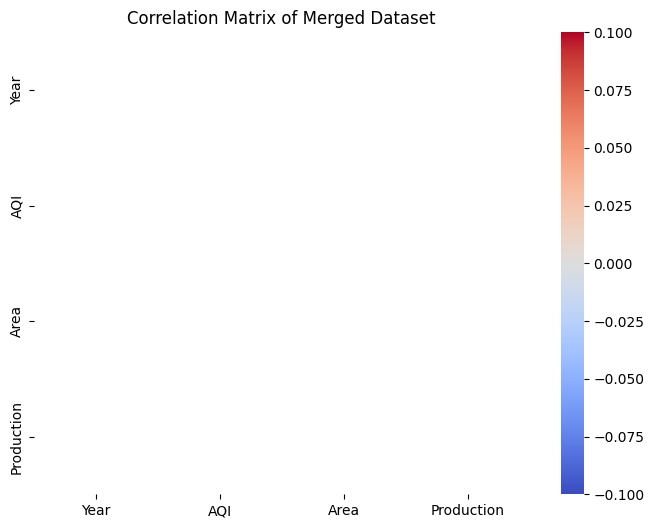

In [15]:
plt.figure(figsize=(8,6))

corr = merged.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Merged Dataset")

plt.show()